# Notebook 07 — Inference Demo

End-to-end demonstration: **PDF file in → hallucination-risk score out.**

This notebook loads the trained ResNet50 checkpoint and calibrator, then
shows how to classify arbitrary PDF pages as:

| Category | Meaning | Probability |
|----------|---------|-------------|
| `safe_for_extraction` | Page is safe for automated text extraction | prob < T_low |
| `review` | Uncertain — route to human review | T_low ≤ prob ≤ T_high |
| `high_hallucination_risk` | Handwritten / questionnaire — extraction will hallucinate | prob > T_high |


In [13]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from PIL import Image

from src.data.render_pdf import render_page
from src.models.resnet_baseline import ResNetClassifier
from src.models.calibrator import TemperatureCalibrator

ROOT = Path('..').resolve()

CHECKPOINT_PATH  = ROOT / 'checkpoints' / 'baseline' / 'resnet50_best.pt'
CALIBRATOR_PATH  = ROOT / 'checkpoints' / 'baseline' / 'resnet50_calibrator.pkl'

DPI         = 150
IMAGE_SIZE  = (224, 224)
GRAYSCALE   = True

## 1 — Load Model & Calibrator

In [14]:
device = torch.device('cpu')

model = ResNetClassifier(model_name='resnet50', pretrained=False, num_classes=1)
state_dict = torch.load(CHECKPOINT_PATH, map_location='cpu')
if 'model_state_dict' in state_dict:
    state_dict = state_dict['model_state_dict']
model.load_state_dict(state_dict)
model.eval()
print(f'Model loaded from {CHECKPOINT_PATH.name}')

calibrator = TemperatureCalibrator()
calibrator.load(str(CALIBRATOR_PATH))
print(f'Calibrator loaded  — temperature = {calibrator.temperature:.4f}')
print(f'Thresholds         — T_low = {calibrator.t_low}, T_high = {calibrator.t_high}')

Model loaded from resnet50_best.pt
Calibrator loaded  — temperature = 1.4896
Thresholds         — T_low = 0.8784884012799996, T_high = 0.9392442006399998


## 2 — Inference Pipeline

The `predict_pdf` function handles the full pipeline:

1. **Render** — converts PDF page → 224×224 grayscale image (PyMuPDF)
2. **Transform** — converts PIL image → normalised tensor (matching training)
3. **Forward** — runs the ResNet50 classifier → raw logit
4. **Calibrate** — temperature-scales the logit → calibrated probability
5. **Classify** — applies thresholds → risk category

In [15]:
inference_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])


def predict_pdf(pdf_path, model=model, calibrator=calibrator,
                t_low=None, t_high=None):
    """
    End-to-end inference on a single PDF page.

    Args:
        pdf_path: str or Path to a single-page PDF.
        model:    loaded ResNetClassifier in eval mode.
        calibrator: fitted TemperatureCalibrator.
        t_low:    safe threshold (default: from calibrator).
        t_high:   risky threshold (default: from calibrator).

    Returns:
        dict with keys: pdf_path, raw_logit, calibrated_prob,
                        risk_category, rendered_image
    """
    if t_low is None:
        t_low = calibrator.t_low if calibrator.t_low is not None else 0.3
    if t_high is None:
        t_high = calibrator.t_high if calibrator.t_high is not None else 0.7

    img = render_page(str(pdf_path), dpi=DPI, grayscale=GRAYSCALE,
                      target_size=IMAGE_SIZE)

    tensor = inference_transform(img).unsqueeze(0)  # [1, 3, 224, 224]

    with torch.no_grad():
        logit = model(tensor).squeeze().item()

    prob = float(calibrator.predict(np.array([logit]))[0])

    if prob < t_low:
        category = 'safe_for_extraction'
    elif prob > t_high:
        category = 'high_hallucination_risk'
    else:
        category = 'review'

    return {
        'pdf_path': str(pdf_path),
        'raw_logit': logit,
        'calibrated_prob': prob,
        'risk_category': category,
        'rendered_image': img,
    }


def predict_pdf_batch(pdf_paths, model=model, calibrator=calibrator,
                      t_low=None, t_high=None):
    """Run predict_pdf on multiple PDF files. Returns list of result dicts."""
    return [predict_pdf(p, model, calibrator, t_low, t_high) for p in pdf_paths]

## 3 — Demo: Classify Test PDFs

We pick sample pages from the held-out test set — two **safe** (regular forms)
and two **risky** (handwritten/questionnaires) — and run them through the pipeline.

In [16]:
DATA_DIR = ROOT / 'data'

demo_pdfs = [
    ('Safe — regular form',  DATA_DIR / 'regular_forms' / '2cef1ae8-c6d5-4905-a062-5c0e79438fc1_page_0002.pdf'),
    ('Safe — regular form',  DATA_DIR / 'regular_forms' / '2cef1ae8-c6d5-4905-a062-5c0e79438fc1_page_0006.pdf'),
    ('Risky — handwritten',  DATA_DIR / 'handwritten'   / '2-14\u05e8\u05d5\u05ea_\u05d0\u05e9\u05d5\u05d0\u05dc_\u05e7\u05d8\u05d9\u05e0\u05d4_20260222_095102_page_0011.pdf'),
    ('Risky — handwritten',  DATA_DIR / 'handwritten'   / '2-14\u05e8\u05d5\u05ea_\u05d0\u05e9\u05d5\u05d0\u05dc_\u05e7\u05d8\u05d9\u05e0\u05d4_20260222_095102_page_0013.pdf'),
]

results = []
for label, pdf_path in demo_pdfs:
    if not pdf_path.exists():
        print(f'  SKIP (not found): {pdf_path.name}')
        continue
    res = predict_pdf(pdf_path)
    res['ground_truth'] = label
    results.append(res)
    print(f'{label:25s} | prob={res["calibrated_prob"]:.3f} | {res["risk_category"]}')

Safe — regular form       | prob=0.000 | safe_for_extraction
Safe — regular form       | prob=0.001 | safe_for_extraction
Risky — handwritten       | prob=0.999 | high_hallucination_risk
Risky — handwritten       | prob=0.999 | high_hallucination_risk


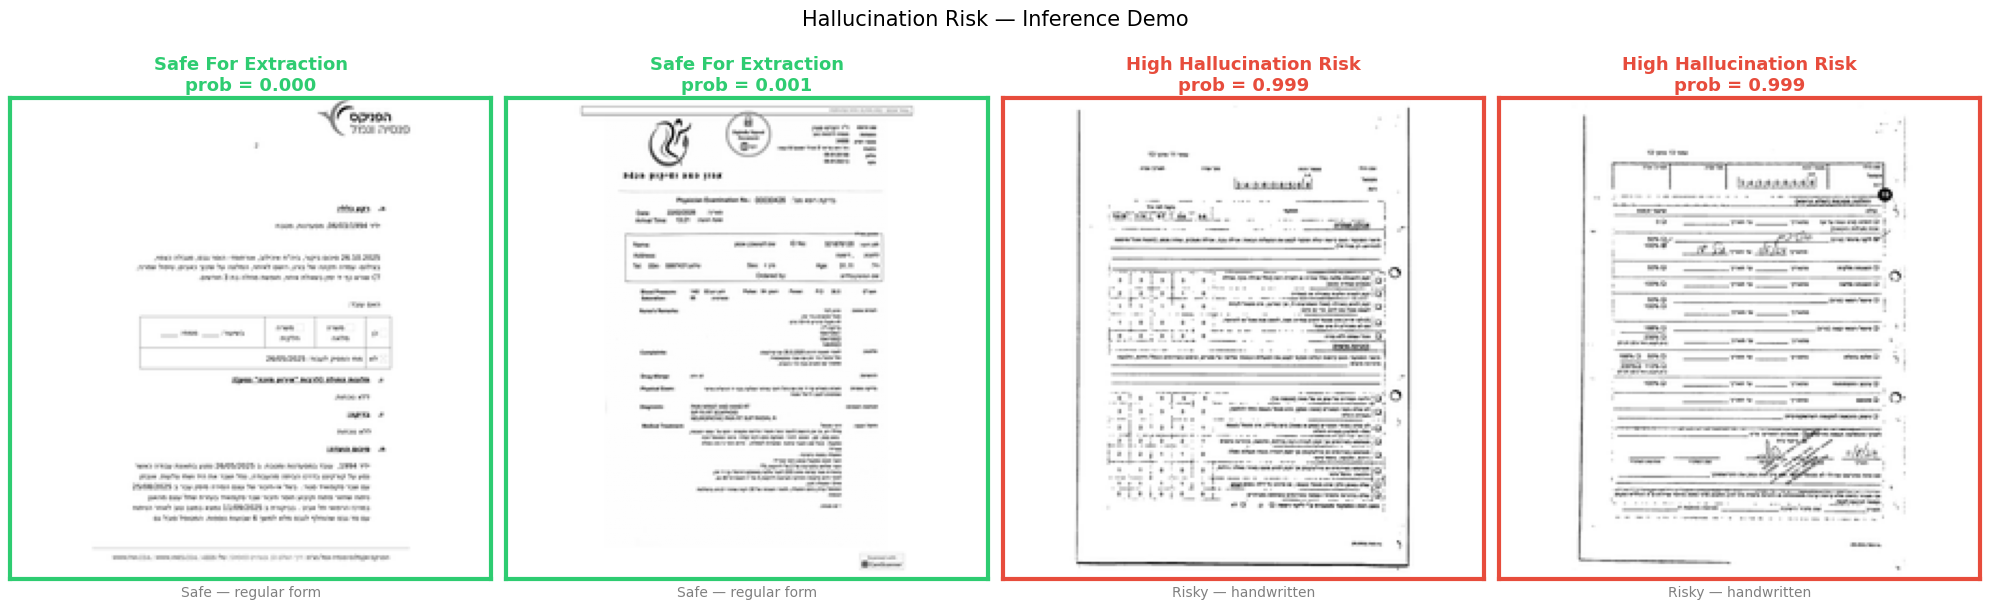

In [17]:
CATEGORY_COLORS = {
    'safe_for_extraction':      '#2ecc71',
    'review':                   '#f39c12',
    'high_hallucination_risk':  '#e74c3c',
}

n = len(results)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 6))
if n == 1:
    axes = [axes]

for ax, res in zip(axes, results):
    ax.imshow(res['rendered_image'], cmap='gray')
    cat   = res['risk_category']
    prob  = res['calibrated_prob']
    color = CATEGORY_COLORS[cat]
    cat_display = cat.replace('_', ' ').title()
    ax.set_title(f'{cat_display}\nprob = {prob:.3f}', fontsize=13,
                 color=color, fontweight='bold')
    ax.set_xlabel(res['ground_truth'], fontsize=10, color='gray')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color(color)
        spine.set_linewidth(3)

fig.suptitle('Hallucination Risk — Inference Demo', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 4 — Classify Your Own PDFs

Point `my_pdfs` at any list of single-page PDF paths to classify them.

In [18]:
# ── Replace these paths with your own PDFs ─────────────────────────────────
my_pdfs = [
    # Path('/path/to/your/document_page_0001.pdf'),
    # Path('/path/to/your/another_doc.pdf'),
]

for pdf_path in my_pdfs:
    pdf_path = Path(pdf_path)
    if not pdf_path.exists():
        print(f'File not found: {pdf_path}')
        continue

    res = predict_pdf(pdf_path)

    print(f'\n{"=" * 60}')
    print(f'File:       {pdf_path.name}')
    print(f'Raw logit:  {res["raw_logit"]:+.4f}')
    print(f'Prob:       {res["calibrated_prob"]:.4f}')
    print(f'Category:   {res["risk_category"]}')
    print(f'{"=" * 60}')

    fig, ax = plt.subplots(figsize=(4, 5))
    ax.imshow(res['rendered_image'], cmap='gray')
    color = CATEGORY_COLORS[res['risk_category']]
    ax.set_title(f'{res["risk_category"].replace("_", " ").title()}\n'
                 f'prob = {res["calibrated_prob"]:.3f}',
                 color=color, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

## 5 — Batch Scoring a Directory

Scan an entire folder of PDFs and produce a summary table.

In [19]:
import pandas as pd

def score_directory(pdf_dir, glob_pattern='*.pdf'):
    """
    Scores all PDFs in a directory and returns a DataFrame.

    Args:
        pdf_dir: path to directory containing PDF files.
        glob_pattern: file pattern (default: '*.pdf').

    Returns:
        pd.DataFrame with columns: file, prob, category, raw_logit
    """
    pdf_dir = Path(pdf_dir)
    pdf_files = sorted(pdf_dir.glob(glob_pattern))
    if not pdf_files:
        print(f'No PDFs found in {pdf_dir}')
        return pd.DataFrame()

    rows = []
    for pdf_path in pdf_files:
        try:
            res = predict_pdf(pdf_path)
            rows.append({
                'file': pdf_path.name,
                'prob': res['calibrated_prob'],
                'category': res['risk_category'],
                'raw_logit': res['raw_logit'],
            })
        except Exception as e:
            rows.append({
                'file': pdf_path.name,
                'prob': None,
                'category': 'error',
                'raw_logit': None,
            })
            print(f'  Error on {pdf_path.name}: {e}')

    df = pd.DataFrame(rows)
    print(f'\nScored {len(df)} files:')
    print(df['category'].value_counts().to_string())
    return df

In [20]:
# Example: score the first 10 regular-form PDFs
sample_dir = DATA_DIR / 'regular_forms'
sample_pdfs = sorted(sample_dir.glob('*.pdf'))[:10]

rows = []
for p in sample_pdfs:
    res = predict_pdf(p)
    rows.append({'file': p.name, 'prob': f'{res["calibrated_prob"]:.3f}',
                 'category': res['risk_category']})

pd.DataFrame(rows)

,file,prob,category
0,2cef1ae8-c6d5-4905-a062-5c0e79438fc1_page_0001...,0.001,safe_for_extraction
1,2cef1ae8-c6d5-4905-a062-5c0e79438fc1_page_0002...,0.000,safe_for_extraction
2,2cef1ae8-c6d5-4905-a062-5c0e79438fc1_page_0003...,0.000,safe_for_extraction
3,2cef1ae8-c6d5-4905-a062-5c0e79438fc1_page_0004...,0.000,safe_for_extraction
4,2cef1ae8-c6d5-4905-a062-5c0e79438fc1_page_0005...,0.068,safe_for_extraction
5,2cef1ae8-c6d5-4905-a062-5c0e79438fc1_page_0006...,0.001,safe_for_extraction
6,2cef1ae8-c6d5-4905-a062-5c0e79438fc1_page_0007...,0.000,safe_for_extraction
7,7eab033e-0e68-46c2-aff0-6a585129fa00_page_0001...,0.000,safe_for_extraction
8,7eab033e-0e68-46c2-aff0-6a585129fa00_page_0002...,0.000,safe_for_extraction
9,7eab033e-0e68-46c2-aff0-6a585129fa00_page_0003...,0.000,safe_for_extraction


## 6 — Full Test-Set Evaluation

Score every page in the held-out test split and show the confusion matrix.

In [21]:
metadata = pd.read_csv(ROOT / 'data' / 'metadata.csv')
test_df  = metadata[metadata['split'] == 'test'].copy()

probs, cats, logits = [], [], []
for _, row in test_df.iterrows():
    fname = row['file_path']
    # Try both directories
    for subdir in ['regular_forms', 'handwritten']:
        candidate = DATA_DIR / subdir / fname
        if candidate.exists():
            res = predict_pdf(candidate)
            probs.append(res['calibrated_prob'])
            cats.append(res['risk_category'])
            logits.append(res['raw_logit'])
            break
    else:
        probs.append(None)
        cats.append('missing')
        logits.append(None)

test_df['prob']      = probs
test_df['category']  = cats
test_df['raw_logit'] = logits

scored = test_df[test_df['category'] != 'missing']
print(f'Scored {len(scored)}/{len(test_df)} test pages\n')
print('Category breakdown:')
print(scored['category'].value_counts().to_string())

print(f'\nCross-tab  (rows=ground truth, cols=prediction):')
label_map = {0: 'safe', 1: 'risky'}
scored_copy = scored.copy()
scored_copy['true_label'] = scored_copy['label_binary'].map(label_map)
print(pd.crosstab(scored_copy['true_label'], scored_copy['category'], margins=True))

Scored 152/152 test pages

Category breakdown:
category
safe_for_extraction        95
high_hallucination_risk    57

Cross-tab  (rows=ground truth, cols=prediction):
category    high_hallucination_risk  safe_for_extraction  All
true_label                                                   
risky                            57                    0   57
safe                              0                   95   95
All                              57                   95  152


In [22]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_true = scored['label_binary'].values
y_pred = (scored['prob'].values > 0.5).astype(int)

print(classification_report(
    y_true, y_pred,
    target_names=['Safe (0)', 'Risky (1)'],
    digits=3,
))

              precision    recall  f1-score   support

    Safe (0)      1.000     0.989     0.995        95
   Risky (1)      0.983     1.000     0.991        57

    accuracy                          0.993       152
   macro avg      0.991     0.995     0.993       152
weighted avg      0.994     0.993     0.993       152



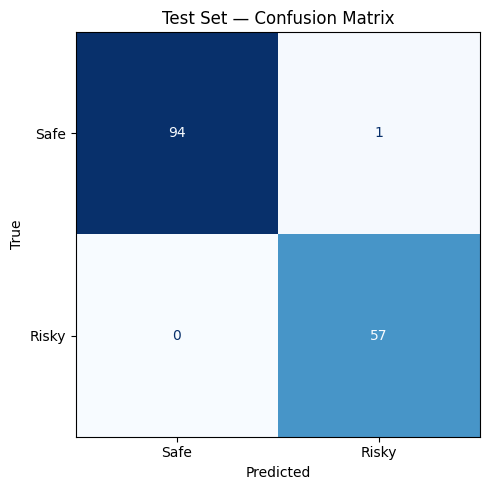

In [23]:
fig, ax = plt.subplots(figsize=(5, 5))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Safe', 'Risky'])
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title('Test Set — Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.show()

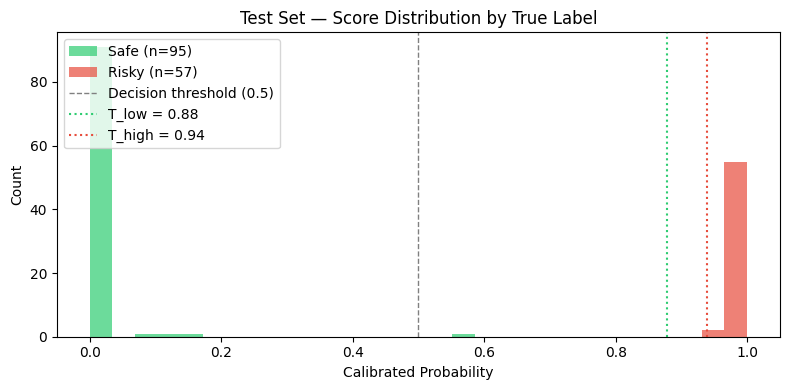

In [24]:
safe_probs  = scored.loc[scored['label_binary'] == 0, 'prob'].values
risky_probs = scored.loc[scored['label_binary'] == 1, 'prob'].values

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 1, 30)
ax.hist(safe_probs,  bins=bins, alpha=0.7, label=f'Safe (n={len(safe_probs)})',  color='#2ecc71')
ax.hist(risky_probs, bins=bins, alpha=0.7, label=f'Risky (n={len(risky_probs)})', color='#e74c3c')
ax.axvline(0.5, color='gray', ls='--', lw=1, label='Decision threshold (0.5)')
if calibrator.t_low is not None:
    ax.axvline(calibrator.t_low,  color='#2ecc71', ls=':', lw=1.5, label=f'T_low = {calibrator.t_low:.2f}')
if calibrator.t_high is not None:
    ax.axvline(calibrator.t_high, color='#e74c3c', ls=':', lw=1.5, label=f'T_high = {calibrator.t_high:.2f}')
ax.set_xlabel('Calibrated Probability')
ax.set_ylabel('Count')
ax.set_title('Test Set — Score Distribution by True Label')
ax.legend()
plt.tight_layout()
plt.show()